In [3]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({
    'figure.figsize': (8,5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'legend.fontsize': 10
})

In [4]:
import os
print(os.listdir('/home/jovyan/work'))

['.ipynb_checkpoints', '2026spring-cse6242-project-description.pdf', 'Artifacts and Content.zip', 'barrel_vs_war.png', 'Baseball_Data_Analysis_Group_187.ipynb', 'baseball_physical_performance_2024.csv', 'baseball_sprint_bio_2024.csv', 'feature_importance.png', 'Field Definitions for Personal Finances Income Data _ OpenSecrets.pdf', 'Field Definitions for Personal Finances Positions Data _ OpenSecrets.pdf', 'height_vs_speed_trend.png', 'height_vs_speed_trend_raw.png', 'height_vs_WAR_by_position.png', 'height_vs_war_clean.png', 'height_weight_vs_WAR.png', 'k_vs_war.png', 'Meeting Summary', 'model_comparison_results.csv', 'model_dataset_used.csv', 'model_feature_importance_updated.csv', 'model_performance.png', 'pitcher_physical_vs_performance.png']


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('/home/jovyan/work/baseball_physical_performance_2024.csv')

print(df.shape)
print(df.columns.tolist())

(566, 39)
['last_name, first_name', 'player_id', 'team_id', 'team', 'age', 'competitive_runs', 'bolts', 'hp_to_1b', 'sprint_speed', 'name', 'height', 'height_in', 'weight', 'position', 'bat_side', 'pitch_hand', 'avg_hit_speed', 'max_hit_speed', 'brl_percent', 'ev95percent', 'Age', 'G', 'PA', 'AVG', 'OBP', 'SLG', 'OPS', 'wOBA', 'wRC+', 'WAR', 'BB%', 'K%', 'ISO', 'BABIP', 'Hard%', 'Barrel%', 'maxEV', 'EV', 'SB']


In [6]:
# ── UPDATED MODELING PIPELINE: SAFE COLUMN VERSION ───────────────────────

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Candidate columns we would like to use
candidate_cols = [
    'name',
    'position',
    'height_in',
    'weight',
    'sprint_speed',
    'avg_hit_speed',
    'brl_percent',
    'WAR',
    'wRC+',
    'wOBA',
    'BB%',
    'K%',
    'Hard%',
    'LA'
]

available_cols = [c for c in candidate_cols if c in df.columns]
missing_cols = [c for c in candidate_cols if c not in df.columns]

print("Available columns:")
print(available_cols)
print("\nMissing columns:")
print(missing_cols)

df_model = df[available_cols].copy().dropna()

print(f"\nModel dataset shape after dropna: {df_model.shape}")

# Require these core columns
required_core = ['position', 'WAR', 'height_in', 'weight', 'sprint_speed', 'avg_hit_speed', 'brl_percent']
for col in required_core:
    if col not in df_model.columns:
        raise ValueError(f"Required column missing: {col}")

# Position-normalized target
df_model['WAR_z'] = df_model.groupby('position')['WAR'].transform(
    lambda x: (x - x.mean()) / x.std()
)

df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna(subset=['WAR_z'])

print(f"Dataset shape after WAR_z creation: {df_model.shape}")
print("\nPositions represented:")
print(df_model['position'].value_counts())

# Baseline feature set
baseline_features = [
    'height_in',
    'weight',
    'sprint_speed',
    'avg_hit_speed',
    'brl_percent'
]

# Expanded feature set only includes columns that actually exist
expanded_candidates = [
    'height_in',
    'weight',
    'sprint_speed',
    'avg_hit_speed',
    'brl_percent',
    'BB%',
    'K%',
    'Hard%',
    'LA'
]
expanded_features = [c for c in expanded_candidates if c in df_model.columns]

print("\nBaseline features:")
print(baseline_features)
print("\nExpanded features:")
print(expanded_features)

target = 'WAR_z'

train_idx, test_idx = train_test_split(
    df_model.index,
    test_size=0.2,
    random_state=42
)

train_df = df_model.loc[train_idx].copy()
test_df = df_model.loc[test_idx].copy()

print(f"\nTrain size: {train_df.shape[0]}")
print(f"Test size:  {test_df.shape[0]}")

def run_model_pipeline(train_df, test_df, feature_cols, target_col, model_name_prefix):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    y_train = train_df[target_col].copy()
    y_test = test_df[target_col].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        f"{model_name_prefix} - Linear": LinearRegression(),
        f"{model_name_prefix} - Ridge": Ridge(alpha=1.0)
    }

    results = []
    coef_tables = []

    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)

        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)

        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

        results.append({
            'Model': model_name,
            'Num_Features': len(feature_cols),
            'Train_R2': round(train_r2, 4),
            'Test_R2': round(test_r2, 4),
            'Test_RMSE': round(test_rmse, 4)
        })

        coef_df = pd.DataFrame({
            'Model': model_name,
            'Feature': feature_cols,
            'Coefficient': model.coef_,
            'Abs_Coefficient': np.abs(model.coef_)
        }).sort_values('Abs_Coefficient', ascending=False)

        coef_tables.append(coef_df)

    results_df = pd.DataFrame(results)
    coefs_df = pd.concat(coef_tables, ignore_index=True)

    return results_df, coefs_df

baseline_results, baseline_coefs = run_model_pipeline(
    train_df=train_df,
    test_df=test_df,
    feature_cols=baseline_features,
    target_col=target,
    model_name_prefix='Baseline'
)

expanded_results, expanded_coefs = run_model_pipeline(
    train_df=train_df,
    test_df=test_df,
    feature_cols=expanded_features,
    target_col=target,
    model_name_prefix='Expanded'
)

all_results = pd.concat([baseline_results, expanded_results], ignore_index=True)
all_coefs = pd.concat([baseline_coefs, expanded_coefs], ignore_index=True)

print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(all_results.sort_values(['Test_R2', 'Train_R2'], ascending=False))

print("\n=== BASELINE FEATURE IMPORTANCE ===")
for model_name in baseline_coefs['Model'].unique():
    print(f"\n{model_name}")
    print(
        baseline_coefs[baseline_coefs['Model'] == model_name][
            ['Feature', 'Coefficient']
        ].to_string(index=False)
    )

print("\n=== EXPANDED FEATURE IMPORTANCE ===")
for model_name in expanded_coefs['Model'].unique():
    print(f"\n{model_name}")
    print(
        expanded_coefs[expanded_coefs['Model'] == model_name][
            ['Feature', 'Coefficient']
        ].to_string(index=False)
    )

best_model_row = all_results.sort_values('Test_R2', ascending=False).iloc[0]
best_model_name = best_model_row['Model']

best_model_coefs = all_coefs[all_coefs['Model'] == best_model_name].copy()
best_model_coefs = best_model_coefs.sort_values('Abs_Coefficient', ascending=False)

print("\n=== BEST MODEL SUMMARY ===")
print(best_model_row.to_string())

print("\nTop predictors in best model:")
print(best_model_coefs[['Feature', 'Coefficient']].head(10).to_string(index=False))

all_results.to_csv('/home/jovyan/work/model_comparison_results.csv', index=False)
all_coefs.to_csv('/home/jovyan/work/model_feature_importance_updated.csv', index=False)
df_model.to_csv('/home/jovyan/work/model_dataset_used.csv', index=False)

print("\nSaved files:")
print("  model_comparison_results.csv")
print("  model_feature_importance_updated.csv")
print("  model_dataset_used.csv")

Available columns:
['name', 'position', 'height_in', 'weight', 'sprint_speed', 'avg_hit_speed', 'brl_percent', 'WAR', 'wRC+', 'wOBA', 'BB%', 'K%', 'Hard%']

Missing columns:
['LA']

Model dataset shape after dropna: (429, 13)
Dataset shape after WAR_z creation: (427, 14)

Positions represented:
position
RF    60
C     59
1B    56
LF    55
3B    50
CF    45
2B    45
SS    43
OF     8
DH     6
Name: count, dtype: int64

Baseline features:
['height_in', 'weight', 'sprint_speed', 'avg_hit_speed', 'brl_percent']

Expanded features:
['height_in', 'weight', 'sprint_speed', 'avg_hit_speed', 'brl_percent', 'BB%', 'K%', 'Hard%']

Train size: 341
Test size:  86

=== MODEL PERFORMANCE COMPARISON ===
               Model  Num_Features  Train_R2  Test_R2  Test_RMSE
3   Expanded - Ridge             8    0.4554   0.4798     0.7299
2  Expanded - Linear             8    0.4554   0.4792     0.7303
0  Baseline - Linear             5    0.2471   0.2552     0.8734
1   Baseline - Ridge             5    0.247

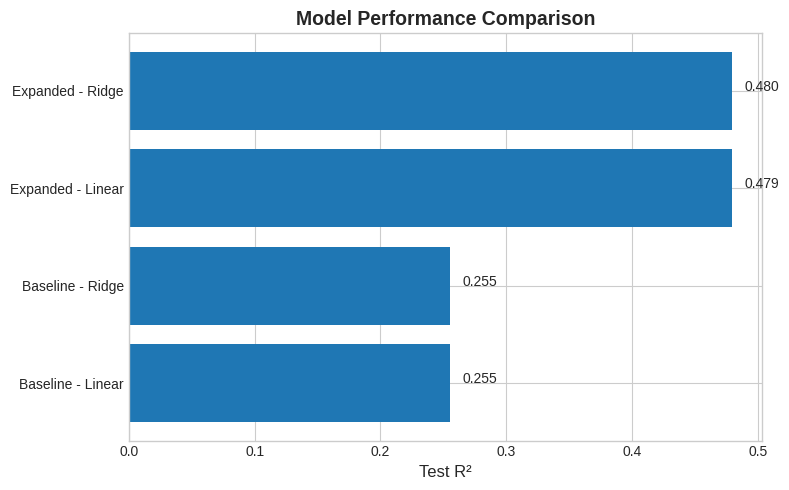

In [7]:
import matplotlib.pyplot as plt

# Extract results
plot_df = all_results.copy()

plt.figure(figsize=(8,5))
plt.barh(plot_df['Model'], plot_df['Test_R2'])
plt.xlabel('Test R²')
plt.title('Model Performance Comparison')

for i, v in enumerate(plot_df['Test_R2']):
    plt.text(v + 0.01, i, f"{v:.3f}")

plt.tight_layout()
plt.savefig('/home/jovyan/work/model_performance.png', dpi=150)
plt.show()

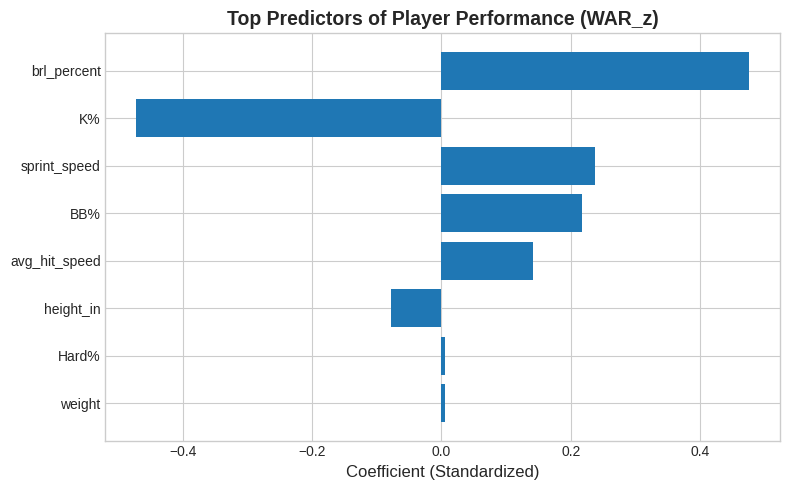

In [8]:
best = best_model_coefs.head(8)

plt.figure(figsize=(8,5))
plt.barh(best['Feature'], best['Coefficient'])
plt.title('Top Predictors of Player Performance (WAR_z)')
plt.xlabel('Coefficient (Standardized)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('/home/jovyan/work/feature_importance.png', dpi=150)
plt.show()

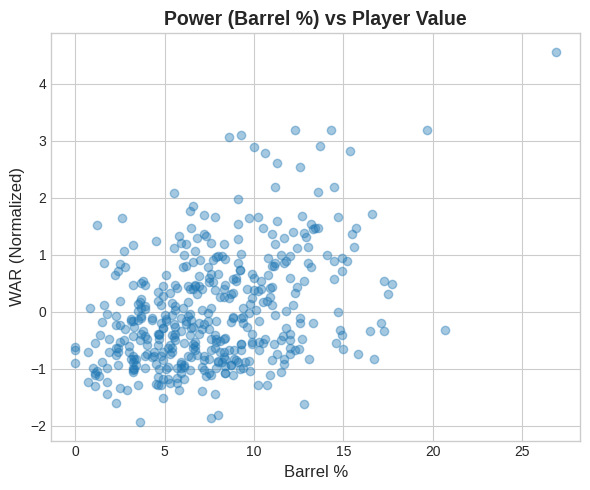

In [9]:
plt.figure(figsize=(6,5))
plt.scatter(df_model['brl_percent'], df_model['WAR_z'], alpha=0.4)
plt.xlabel('Barrel %')
plt.ylabel('WAR (Normalized)')
plt.title('Power (Barrel %) vs Player Value')

plt.tight_layout()
plt.savefig('/home/jovyan/work/barrel_vs_war.png', dpi=150)
plt.show()

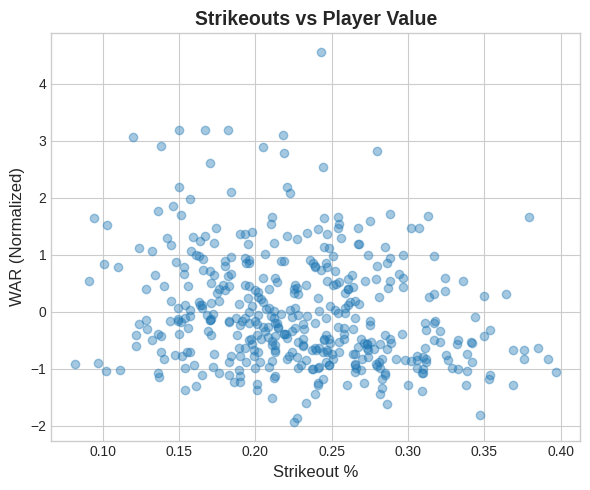

In [10]:
plt.figure(figsize=(6,5))
plt.scatter(df_model['K%'], df_model['WAR_z'], alpha=0.4)
plt.xlabel('Strikeout %')
plt.ylabel('WAR (Normalized)')
plt.title('Strikeouts vs Player Value')

plt.tight_layout()
plt.savefig('/home/jovyan/work/k_vs_war.png', dpi=150)
plt.show()

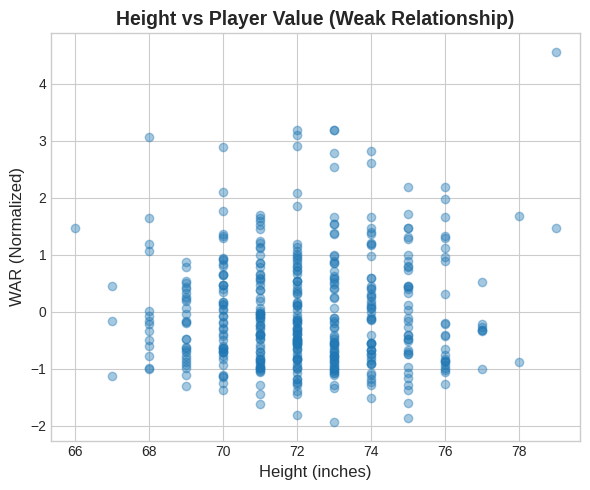

In [11]:
plt.figure(figsize=(6,5))
plt.scatter(df_model['height_in'], df_model['WAR_z'], alpha=0.4)
plt.xlabel('Height (inches)')
plt.ylabel('WAR (Normalized)')
plt.title('Height vs Player Value (Weak Relationship)')

plt.tight_layout()
plt.savefig('/home/jovyan/work/height_vs_war_clean.png', dpi=150)
plt.show()

In [12]:
# =========================
# MULTI-SEASON TREND ANALYSIS
# =========================

Pulling sprint speed for 2019...
Pulling sprint speed for 2021...
Pulling sprint speed for 2022...
Pulling sprint speed for 2023...
Pulling sprint speed for 2024...
Total rows: 2865
Unique players: 1057
Fetching heights...
   season  avg_height_in  avg_sprint_speed  player_count
0    2019      72.482456         27.074211           570
1    2021      72.294643         27.168571           560
2    2022      72.302048         27.232253           586
3    2023      72.195540         27.292624           583
4    2024      72.171378         27.303004           566


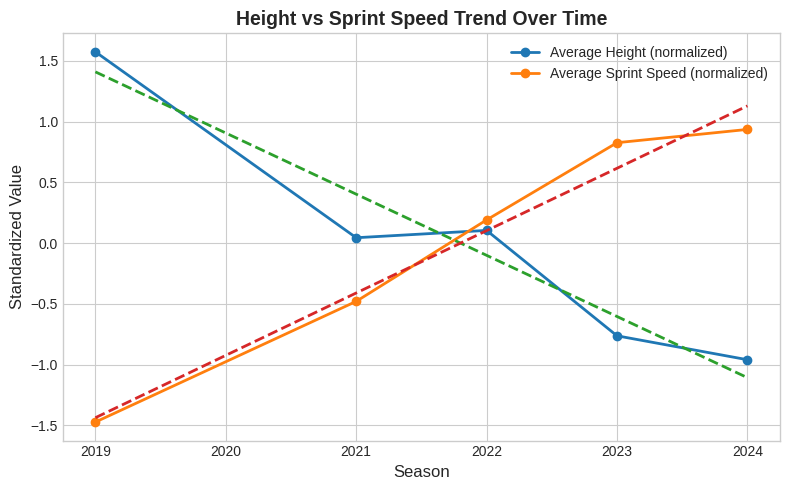

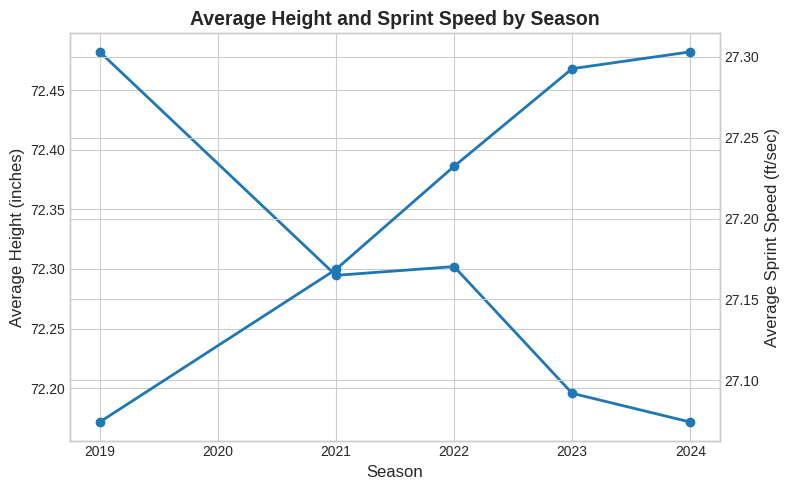

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import pybaseball as pb
import time

pb.cache.enable()

years = [2019, 2021, 2022, 2023, 2024]

def get_player_height(mlbam_id):
    url = f"https://statsapi.mlb.com/api/v1/people/{int(mlbam_id)}"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            people = r.json().get("people", [])
            if people:
                h = people[0].get("height", "")
                try:
                    parts = h.replace('"', '').split("' ")
                    return int(parts[0]) * 12 + int(parts[1])
                except:
                    return np.nan
    except:
        pass
    return np.nan

all_speed = []

for year in years:
    print(f"Pulling sprint speed for {year}...")
    temp = pb.statcast_sprint_speed(year, min_opp=10).copy()
    temp["season"] = year
    all_speed.append(temp)
    time.sleep(1)

multi_speed = pd.concat(all_speed, ignore_index=True)

print("Total rows:", multi_speed.shape[0])
print("Unique players:", multi_speed["player_id"].nunique())

unique_ids = multi_speed["player_id"].dropna().astype(int).unique()

print("Fetching heights...")
height_lookup = pd.DataFrame({
    "player_id": unique_ids,
    "height_in": [get_player_height(pid) for pid in unique_ids]
})

multi_speed = multi_speed.merge(height_lookup, on="player_id", how="left")

trend = multi_speed.groupby("season").agg(
    avg_height_in=("height_in", "mean"),
    avg_sprint_speed=("sprint_speed", "mean"),
    player_count=("player_id", "nunique")
).reset_index()

print(trend)

# normalized comparison plot
height_norm = (trend["avg_height_in"] - trend["avg_height_in"].mean()) / trend["avg_height_in"].std()
speed_norm = (trend["avg_sprint_speed"] - trend["avg_sprint_speed"].mean()) / trend["avg_sprint_speed"].std()

plt.figure(figsize=(8, 5))
plt.plot(trend["season"], height_norm, marker="o", label="Average Height (normalized)")
plt.plot(trend["season"], speed_norm, marker="o", label="Average Sprint Speed (normalized)")

z_h = np.polyfit(trend["season"], height_norm, 1)
z_s = np.polyfit(trend["season"], speed_norm, 1)

plt.plot(trend["season"], np.poly1d(z_h)(trend["season"]), linestyle="--")
plt.plot(trend["season"], np.poly1d(z_s)(trend["season"]), linestyle="--")

plt.xlabel("Season")
plt.ylabel("Standardized Value")
plt.title("Height vs Sprint Speed Trend Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("/home/jovyan/work/height_vs_speed_trend.png", dpi=150)
plt.show()

# optional raw-value chart
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(trend["season"], trend["avg_height_in"], marker="o")
ax1.set_xlabel("Season")
ax1.set_ylabel("Average Height (inches)")

ax2 = ax1.twinx()
ax2.plot(trend["season"], trend["avg_sprint_speed"], marker="o")
ax2.set_ylabel("Average Sprint Speed (ft/sec)")

plt.title("Average Height and Sprint Speed by Season")
plt.tight_layout()
plt.savefig("/home/jovyan/work/height_vs_speed_trend_raw.png", dpi=150)
plt.show()

In [ ]:
#================================
#Team Level Competitive Analysis
#===============================

In [14]:
team_stats = df.groupby('team').agg({
    'height_in': 'mean',
    'weight': 'mean',
    'sprint_speed': 'mean',
    'WAR': 'sum'
}).reset_index()

team_stats.rename(columns={
    'height_in': 'avg_height',
    'weight': 'avg_weight',
    'sprint_speed': 'avg_speed',
    'WAR': 'team_WAR'
}, inplace=True)

print(team_stats.head())

  team  avg_height  avg_weight  avg_speed  team_WAR
0  ATH   72.800000  203.050000  27.485000      13.5
1  ATL   72.000000  206.666667  27.076190      18.1
2   AZ   71.400000  203.750000  26.790000      34.0
3  BAL   73.117647  214.411765  27.641176      26.9
4  BOS   71.428571  208.380952  27.385714      23.1


In [15]:
import requests
import pandas as pd

def get_mlb_team_records(season=2024):
    """
    Pull MLB team win/loss records from the public MLB Stats API standings endpoint.
    Returns one row per MLB team.
    """
    url = "https://statsapi.mlb.com/api/v1/standings"
    params = {
        "leagueId": "103,104",   # AL + NL
        "season": season,
        "standingsTypes": "regularSeason"
    }

    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    rows = []
    for record_group in data.get("records", []):
        for team_rec in record_group.get("teamRecords", []):
            team = team_rec.get("team", {})
            rows.append({
                "season": season,
                "team_id": team.get("id"),
                "team_name": team.get("name"),
                "team_abbr": team.get("abbreviation"),
                "wins": team_rec.get("wins"),
                "losses": team_rec.get("losses"),
                "win_pct": float(team_rec.get("winningPercentage")) if team_rec.get("winningPercentage") else None,
                "runs_scored": team_rec.get("runsScored"),
                "runs_allowed": team_rec.get("runsAllowed"),
                "run_differential": team_rec.get("runDifferential"),
                "sport_rank": team_rec.get("sportRank"),
                "league_rank": team_rec.get("leagueRank"),
                "division_rank": team_rec.get("divisionRank"),
            })

    df_records = pd.DataFrame(rows)

    # De-dup just in case
    df_records = df_records.drop_duplicates(subset=["season", "team_id"]).reset_index(drop=True)
    return df_records

team_records_2024 = get_mlb_team_records(2024)
print(team_records_2024.shape)
team_records_2024.head()

(30, 13)


,season,team_id,team_name,team_abbr,wins,losses,win_pct,runs_scored,runs_allowed,run_differential,sport_rank,league_rank,division_rank
0,2024,147,Yankees,None,94,68,0.580,815,668,147,3,1,1
1,2024,110,Orioles,None,91,71,0.562,786,699,87,7,3,2
2,2024,111,Red Sox,None,81,81,0.500,751,747,4,18,9,3
3,2024,139,Rays,None,80,82,0.494,604,663,-59,20,10,4
4,2024,141,Blue Jays,None,74,88,0.457,671,743,-72,24,12,5


In [16]:
team_profile = (
    df.groupby("team")
      .agg(
          avg_height=("height_in", "mean"),
          avg_weight=("weight", "mean"),
          avg_speed=("sprint_speed", "mean"),
          total_war=("WAR", "sum"),
          player_count=("player_id", "nunique")
      )
      .reset_index()
)

print(team_profile.shape)
team_profile.head()

(30, 6)


,team,avg_height,avg_weight,avg_speed,total_war,player_count
0,ATH,72.800000,203.050000,27.485000,13.5,20
1,ATL,72.000000,206.666667,27.076190,18.1,21
2,AZ,71.400000,203.750000,26.790000,34.0,20
3,BAL,73.117647,214.411765,27.641176,26.9,17
4,BOS,71.428571,208.380952,27.385714,23.1,21


In [17]:
print("Player dataset team values:")
print(sorted(team_profile["team"].dropna().unique()))

print("\nStandings API abbreviations:")
print(sorted(team_records_2024["team_abbr"].dropna().unique()))

print("\nStandings API names:")
print(sorted(team_records_2024["team_name"].dropna().unique())[:10])

Player dataset team values:
['ATH', 'ATL', 'AZ', 'BAL', 'BOS', 'CHC', 'CIN', 'CLE', 'COL', 'CWS', 'DET', 'HOU', 'KC', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM', 'NYY', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'STL', 'TB', 'TEX', 'TOR', 'WSH']

Standings API abbreviations:
[]

Standings API names:
['Angels', 'Astros', 'Athletics', 'Blue Jays', 'Braves', 'Brewers', 'Cardinals', 'Cubs', 'D-backs', 'Dodgers']


In [18]:
team_name_to_abbr = {
    'Angels': 'LAA',
    'Astros': 'HOU',
    'Athletics': 'ATH',
    'Blue Jays': 'TOR',
    'Braves': 'ATL',
    'Brewers': 'MIL',
    'Cardinals': 'STL',
    'Cubs': 'CHC',
    'D-backs': 'AZ',
    'Dodgers': 'LAD',
    'Giants': 'SF',
    'Guardians': 'CLE',
    'Mariners': 'SEA',
    'Marlins': 'MIA',
    'Mets': 'NYM',
    'Nationals': 'WSH',
    'Orioles': 'BAL',
    'Padres': 'SD',
    'Phillies': 'PHI',
    'Pirates': 'PIT',
    'Rangers': 'TEX',
    'Rays': 'TB',
    'Red Sox': 'BOS',
    'Reds': 'CIN',
    'Rockies': 'COL',
    'Royals': 'KC',
    'Tigers': 'DET',
    'Twins': 'MIN',
    'White Sox': 'CWS',
    'Yankees': 'NYY'
}

In [19]:
team_records_2024['team_abbr'] = team_records_2024['team_name'].map(team_name_to_abbr)

print(team_records_2024[['team_name','team_abbr']].head())

   team_name team_abbr
0    Yankees       NYY
1    Orioles       BAL
2    Red Sox       BOS
3       Rays        TB
4  Blue Jays       TOR


In [20]:
team_level = team_profile.merge(
    team_records_2024,
    left_on='team',
    right_on='team_abbr',
    how='inner'
)

print(team_level.shape)
team_level[['team','team_name','win_pct','avg_height','avg_weight','avg_speed']].head()

(30, 19)


,team,team_name,win_pct,avg_height,avg_weight,avg_speed
0,ATH,Athletics,0.426,72.800000,203.050000,27.485000
1,ATL,Braves,0.549,72.000000,206.666667,27.076190
2,AZ,D-backs,0.549,71.400000,203.750000,26.790000
3,BAL,Orioles,0.562,73.117647,214.411765,27.641176
4,BOS,Red Sox,0.500,71.428571,208.380952,27.385714


In [22]:
corr = team_level[['avg_height','avg_weight','avg_speed','win_pct']].corr()
print(corr)

            avg_height  avg_weight  avg_speed   win_pct
avg_height    1.000000    0.442102   0.054358 -0.229995
avg_weight    0.442102    1.000000  -0.318792 -0.117529
avg_speed     0.054358   -0.318792   1.000000 -0.016957
win_pct      -0.229995   -0.117529  -0.016957  1.000000


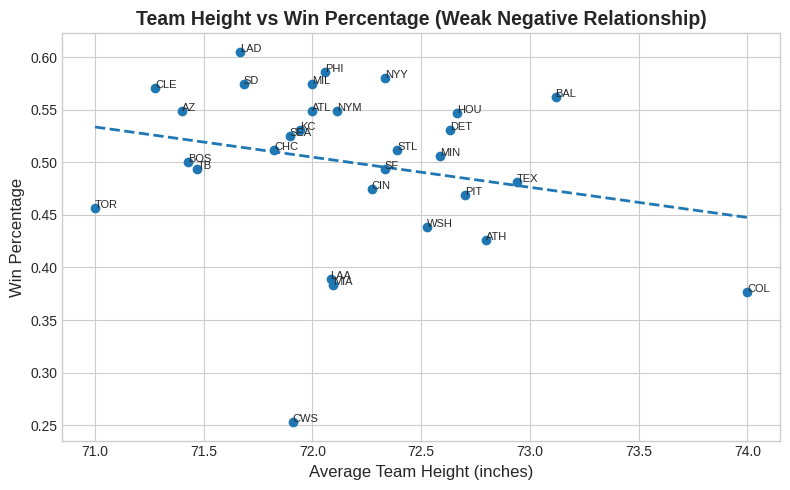

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.scatter(team_level['avg_height'], team_level['win_pct'])

for _, row in team_level.iterrows():
    plt.text(row['avg_height'], row['win_pct'], row['team'], fontsize=8)

z = np.polyfit(team_level['avg_height'], team_level['win_pct'], 1)
p = np.poly1d(z)

x_line = np.linspace(team_level['avg_height'].min(), team_level['avg_height'].max(), 100)
plt.plot(x_line, p(x_line), linestyle='--')

plt.title('Team Height vs Win Percentage (Weak Negative Relationship)')
plt.xlabel('Average Team Height (inches)')
plt.ylabel('Win Percentage')

plt.tight_layout()
plt.show()